In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

<Axes: >

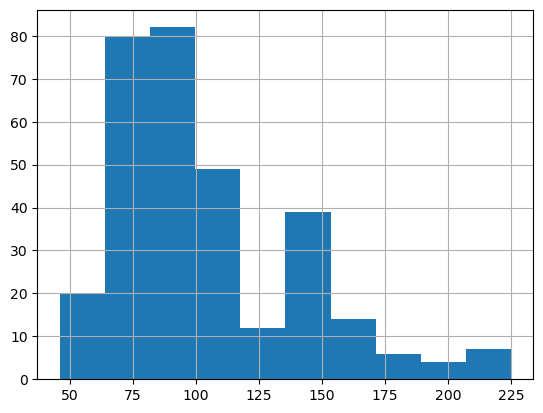

In [15]:
df = pd.read_csv(
    "../data/auto-mpg.data",
    sep=r"\s+",
    names=[
        "mpg", "cylinders", "displacement", "horsepower", "weight",
        "acceleration", "model_year", "origin", "car_name"
    ],
    na_values="?"
)

X = df.drop(["mpg", "car_name"], axis=1)
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train["horsepower"].hist()

In [19]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, ["cylinders", "displacement", "weight",
        "acceleration", "model_year", "horsepower"]),
    ("cat", cat_pipeline, ["origin"])
])

Test R2: 0.8449094399450835
Test MSE: 8.338667873348665
Test RMSE: 2.8876751675610373
Test MAE: 2.288246813885049


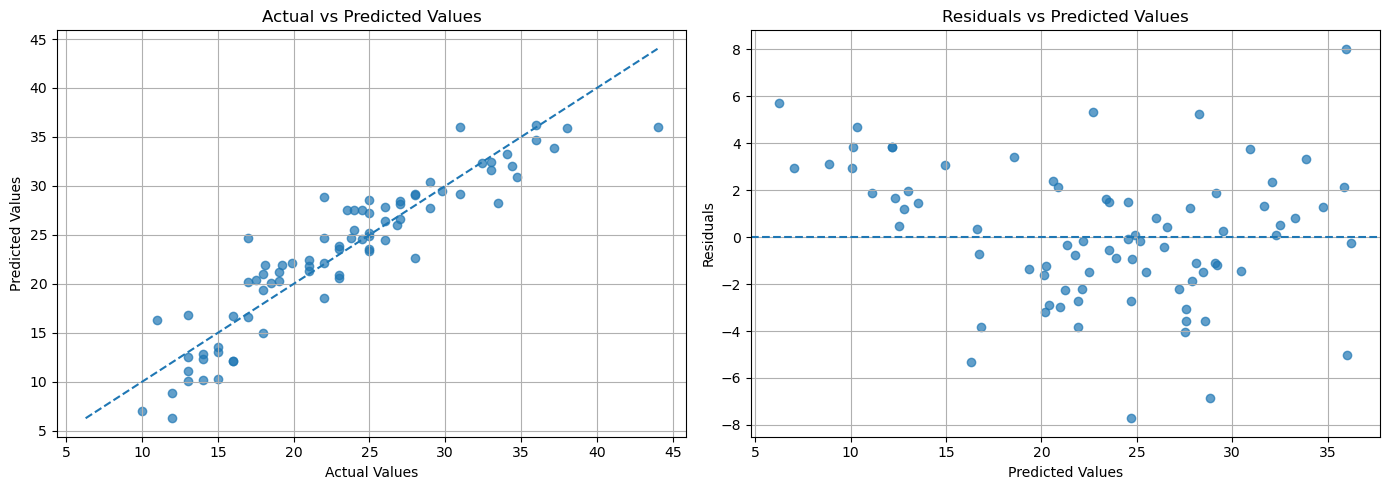

In [20]:
model = make_pipeline(
    preprocessing,
    LinearRegression()
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Test R2:", r2_score(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Test MAE:", mean_absolute_error(y_test, y_pred))

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val], linestyle="--")
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs Predicted Values")
axes[0].grid(True)

# 2. Residuals vs Predicted
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted Values")
axes[1].grid(True)

plt.tight_layout()
plt.show()
